# Example Climb: creating non-linear monotonic relationships

## Goal: Maximize Spearman while minimizing Pearson

This notebook demonstrates using the hill climber to transform data to have a strong monotonic relationship (high Spearman correlation) while maintaining a weak linear relationship (low Pearson correlation). This creates non-linear but monotonic patterns.

## 1. Notebook setup

### 1.1. Imports

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr

sys.path.append('..')

from hill_climber import HillClimber

np.random.seed(315)

### 1.2. Input distributions

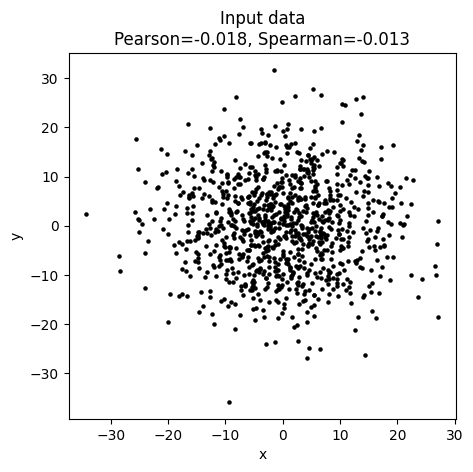

In [2]:
n = 1000
np.random.seed(315)

x = np.random.normal(0, 10, n)
y = np.random.normal(0, 10, n)

data = pd.DataFrame({'x': x, 'y': y})

# Check initial correlations
initial_pearson = pearsonr(data['x'], data['y'])[0]
initial_spearman = spearmanr(data['x'], data['y'])[0]

plt.figure(figsize=(5, 4.75))
plt.scatter(data['x'], data['y'], s=5, color='black')
plt.title(f'Input data\nPearson={initial_pearson:.3f}, Spearman={initial_spearman:.3f}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 2. Optimize for non-linear monotonic relationship
### 2.1. Objective function

**Objective:** Maximize |Spearman| - |Pearson|

In [3]:
def objective_spearman_large_pearson_small(x, y):
    '''Maximize |Spearman| - |Pearson| to create non-linear monotonic relationships.
    
    Objective function: |Spearman| - |Pearson|
    
    This creates a gradient that:
        - Rewards increasing monotonicity (Spearman)
        - Penalizes increasing linearity (Pearson)
        - Works for both positive and negative correlations
        - Accumulates small beneficial changes over time
    
    Args:
        x: First variable (array-like)
        y: Second variable (array-like)
    
    Returns:
        Tuple of (metrics_dict, objective_value) where:
            - metrics_dict: Dict with 'PCC' and 'SCC'
            - objective_value: |Spearman| - |Pearson|
    '''
    
    pearson_corr = pearsonr(x, y)[0]
    spearman_corr = spearmanr(x, y)[0]
    
    # Objective: maximize gap between monotonic and linear correlation
    # Use absolute values to work with both positive and negative correlations
    objective = abs(spearman_corr) - abs(pearson_corr)
    
    metrics = {
        'PCC': pearson_corr,
        'SCC': spearman_corr
    }
    
    return metrics, objective

### 2.2. Hill climbing run

In [4]:
climber = HillClimber(
    data=data,
    objective_func=objective_spearman_large_pearson_small,
    initial_step_spread=0.5,
    final_step_spread=0.00005,
    T_min=0.0001,
    T_max=0.01,
    cooling_rate=1e-5,
    exchange_interval=10,
    max_time=10,
    n_replicas=10,
    db_path='../data/pearson-spearman.db'
)

HillClimber Configuration

Data shape:           (1000, 2)
Optimization mode:    maximize
Max runtime:          10 minutes

Temperature settings:
  T_min:              0.0001
  T_max:              0.01
  Cooling rate:       1e-05
  Temperature scheme: geometric

Replica exchange:
  Number of replicas: 10
  Exchange interval:  10 steps
  Exchange strategy:  even_odd
  Worker processes:   10

Perturbation settings:
  Initial step spread: 0.5 (fraction of range)
  Final step spread:   5e-05 (fraction at end of run)
  Perturb fraction:    0.001

Database settings:
  Enabled:            True
  Path:               ../data/pearson-spearman.db
  Step interval:      1



In [5]:
# Run optimization with replica exchange
best_data_df = climber.climb()

### 2.3. Results

In [7]:
best_data_df.head()

,x,y
0,13.409146,-2.352792
1,13.563907,11.290166
2,19.027772,31.634818
3,-7.631239,-5.665484
4,-9.795265,4.748825


<module 'matplotlib.pyplot' from '/home/vscode/.local/lib/python3.12/site-packages/matplotlib/pyplot.py'>

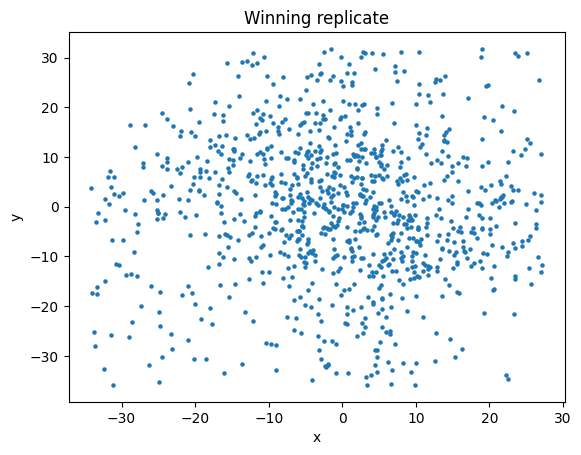

In [8]:
plt.title('Winning replicate')
plt.scatter(best_data_df['x'], best_data_df['y'], s=5)
plt.xlabel('x')
plt.ylabel('y')
plt